# Image classifier

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Flatten, Input, Conv2D
from tensorflow.keras.layers import MaxPooling2D, Dropout
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.utils import set_random_seed, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import accuracy_score




## Carga de datos y visualización de datos de entrada

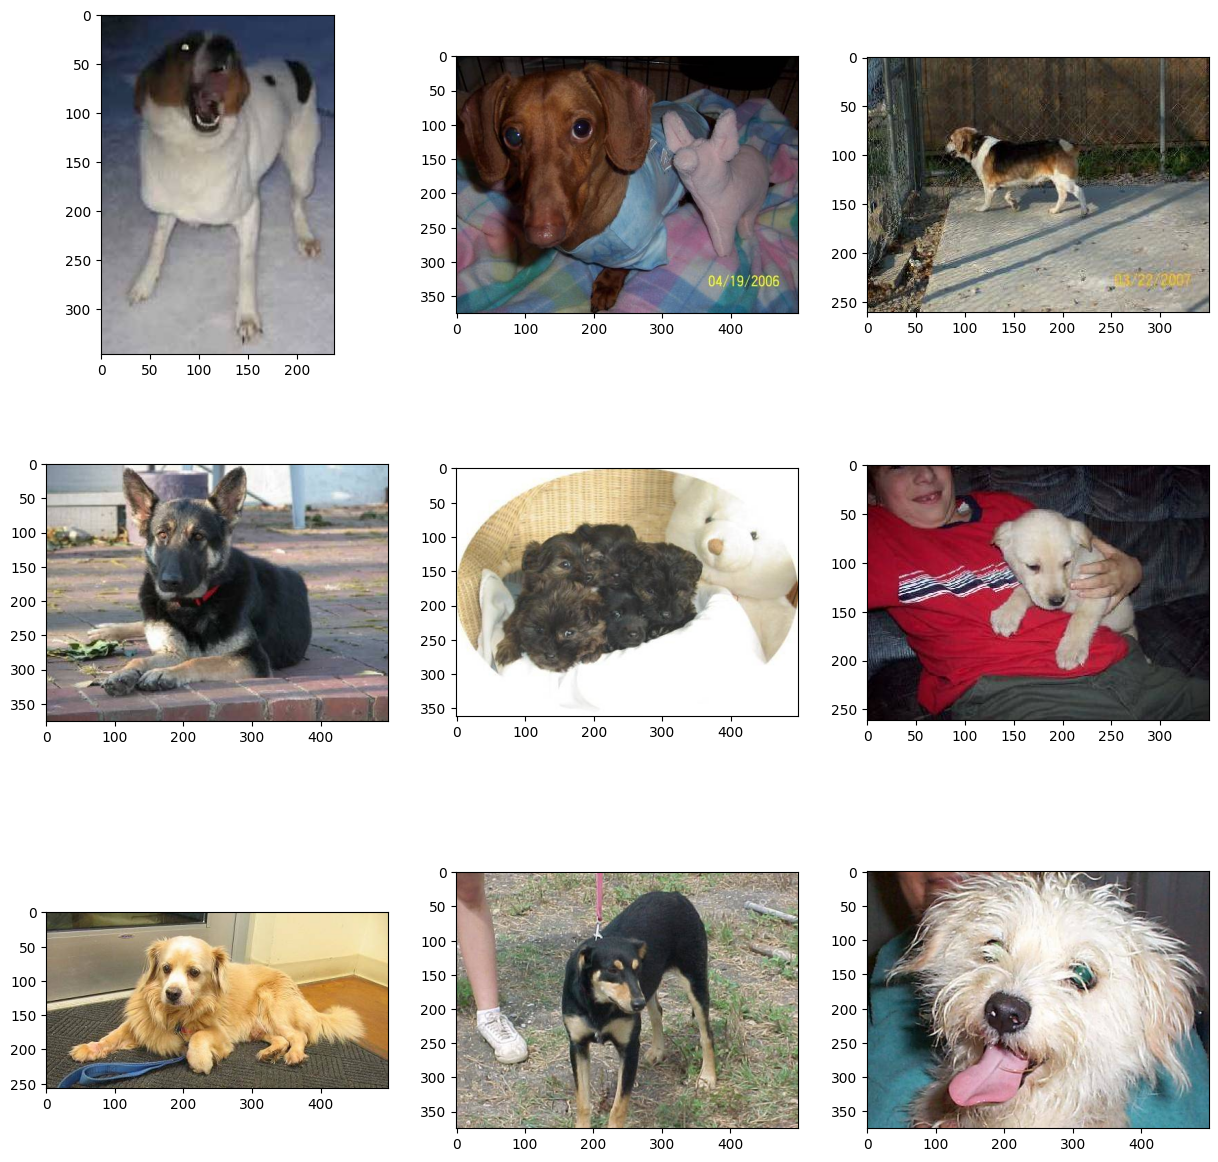

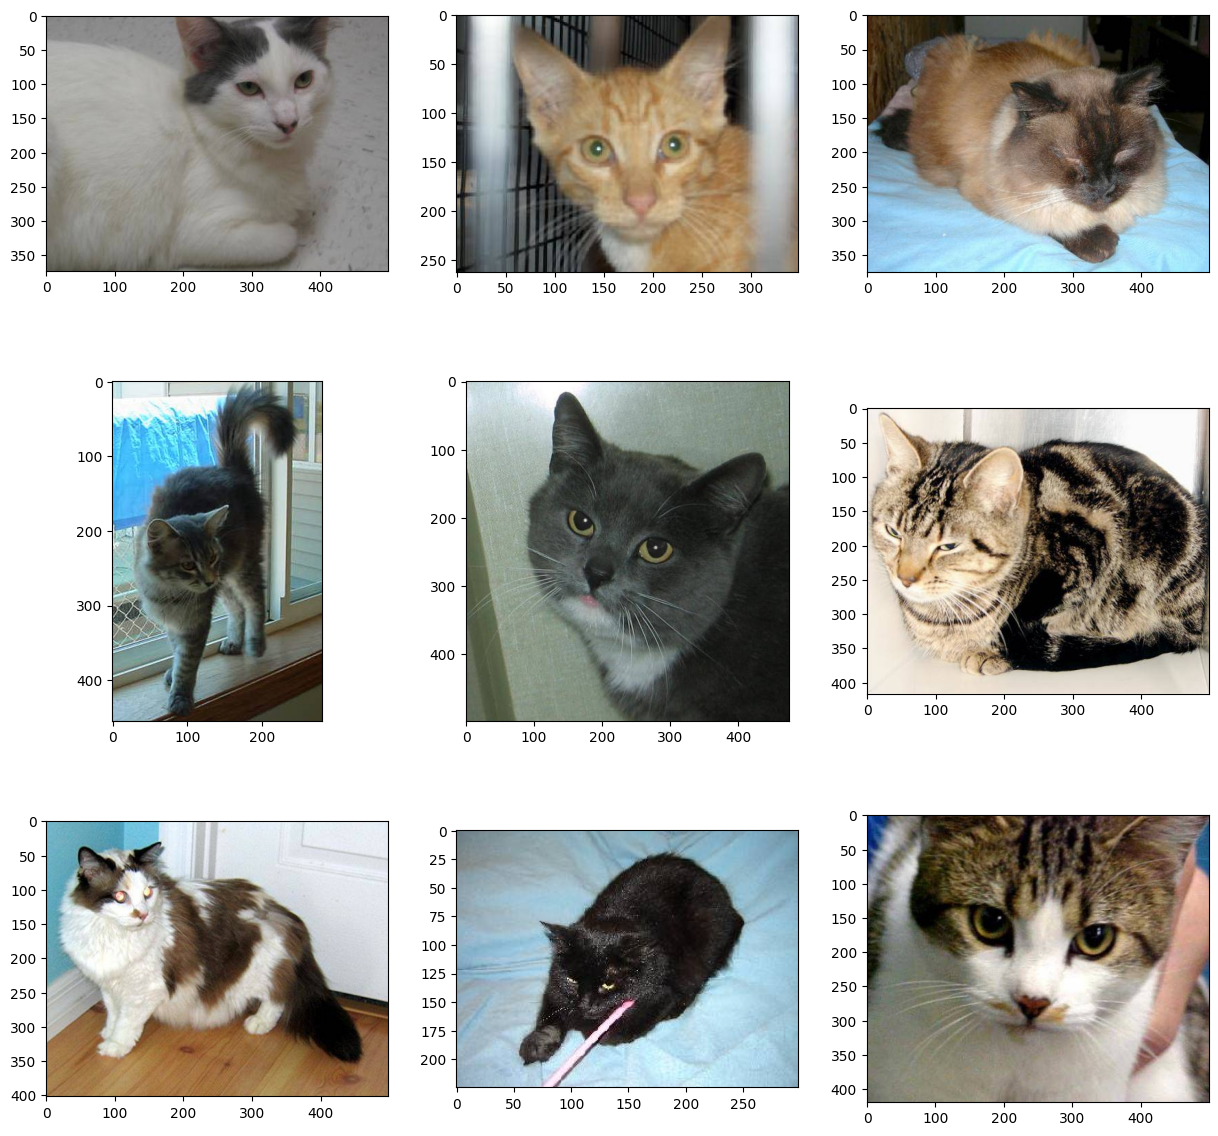

In [2]:
data_train = '/content/drive/MyDrive/DataScience/dogs_vs_cats/train'
data_test = '/content/drive/MyDrive/DataScience/dogs_vs_cats/test'

dogs = os.path.join(data_train, 'dogs')
dog_files = os.listdir(dogs)
cats = os.path.join(data_train, 'cats')
cat_files = os.listdir(cats)

plt.figure(figsize=(15,15))
for i in range(9):
    path = os.path.join(dogs, dog_files[i])
    pic = load_img(path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(pic)
plt.show()

plt.figure(figsize=(15,15))
for i in range(9):
    path = os.path.join(cats, cat_files[i])
    pic = load_img(path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(pic)
plt.show()

>Hemos cargado las carpetas dogs y cats de train y con esos datos hemos mostrado por pantalla las 9 primeras imagenes da cada

## Conjuntos de imagenes para el modelo

>Generamos los conjuntos de imagenes para entrenar el modelo

In [3]:
trndata_gen = ImageDataGenerator(rescale=1./255)
tsdata_gen = ImageDataGenerator(rescale=1./255)

trndata = trndata_gen.flow_from_directory(data_train,
                                        target_size=(128,128),
                                        batch_size=32,
                                        class_mode='categorical',
                                        shuffle=True)

tsdata = tsdata_gen.flow_from_directory(data_test,
                                        target_size=(128,128),
                                        batch_size=32,
                                        class_mode='categorical',
                                        shuffle=False)




Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


>Vemos que son 20000 imagenes en en train y 5000 en el test

In [4]:
images, _ = next(trndata)
images.shape

(32, 128, 128, 3)

>vemos que las imagenes son del formato 128 x 128 pixeles x 3 capas de color, seguramente rgb, una de rojo (red), verde (green) y azul (blue)

## Modelado

In [5]:
model = Sequential()
model.add(Input(shape=(128, 128, 3)))

model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,048,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,072,354 (4.09 MB)

 Trainable params: 1,072,354 (4.09 MB)

 Non-trainable params: 0 (0.00 B)

>Definimos la arquitectura

## Compilación del modelo

In [6]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

>Compilamos el modelo para entrenarlo después

In [7]:
history = model.fit(trndata, epochs=10, validation_data=tsdata)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 534s 850ms/step - accuracy: 0.5643 - loss: 0.6752 - val_accuracy: 0.7434 - val_loss: 0.5319
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 415s 664ms/step - accuracy: 0.7250 - loss: 0.5429 - val_accuracy: 0.7820 - val_loss: 0.4662
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 412s 660ms/step - accuracy: 0.7815 - loss: 0.4636 - val_accuracy: 0.8084 - val_loss: 0.4252
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 418s 669ms/step - accuracy: 0.8204 - loss: 0.4043 - val_accuracy: 0.8322 - val_loss: 0.3807
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 428s 685ms/step - accuracy: 0.8448 - loss: 0.3517 - val_accuracy: 0.8316 - val_loss: 0.3866
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 422s 676ms/step - accuracy: 0.8586 - loss: 0.3215 - val_accuracy: 0.8336 - val_loss: 0.3833
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 448s 685ms/step - accuracy: 0.8812 - loss: 0.2734 - val_accuracy: 0.8490 - val_loss: 0.3644
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 421s 674ms/step - accuracy: 0.8998 -

>Una vez entrenado el modelo de manera básica vemos que tras 10 epocas el accuracy llega a más del 92% pero el val_accuracy a poco más del 85% por lo que tenemos un buen resultado aunque hayamos provocado un poco de Overfitting

## Optimización del modelo

In [8]:
checkpoint = ModelCheckpoint('best_model.h5', monitor="val_accuracy",
                             save_best_only=True, mode="max")
early = EarlyStopping(patience=3,restore_best_weights=True)

hist_top = model.fit(trndata, epochs=15, validation_data=tsdata,
                     callbacks=[checkpoint, early])

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.9340 - loss: 0.1567

625/625 ━━━━━━━━━━━━━━━━━━━━ 420s 672ms/step - accuracy: 0.9340 - loss: 0.1567 - val_accuracy: 0.8494 - val_loss: 0.4378
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 417s 667ms/step - accuracy: 0.9397 - loss: 0.1385 - val_accuracy: 0.8470 - val_loss: 0.4638
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 415s 664ms/step - accuracy: 0.9489 - loss: 0.1201 - val_accuracy: 0.8484 - val_loss: 0.5085
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.9483 - loss: 0.1213

625/625 ━━━━━━━━━━━━━━━━━━━━ 445s 668ms/step - accuracy: 0.9483 - loss: 0.1213 - val_accuracy: 0.8578 - val_loss: 0.5238


>Tras la optimización del modelo notamos similares resultados al sin optimizar pero algo mejorados tanto en el accuracy como en val_accuracy. Este parece que para gracias al early stopping parece que dado al buen resultado que genera de base y la poca mejora que se ve epoca a epoca

## Muestra de resultados

>Mostramos como avanzan los resultados del modelo sin optimizar

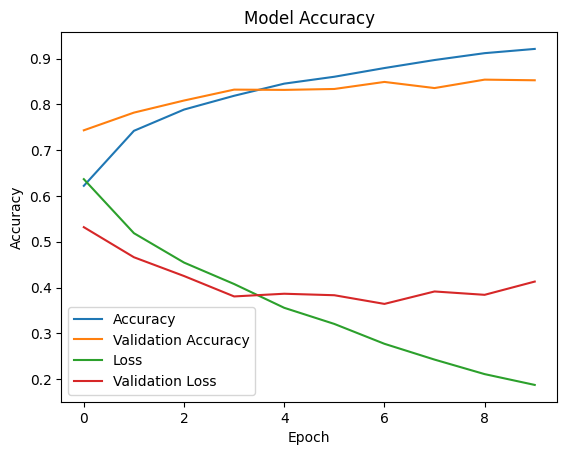

In [9]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Accuracy", "Validation Accuracy", "Loss", "Validation Loss"])

plt.show()

>Ahora mostramos la evolución del modelo optimizado

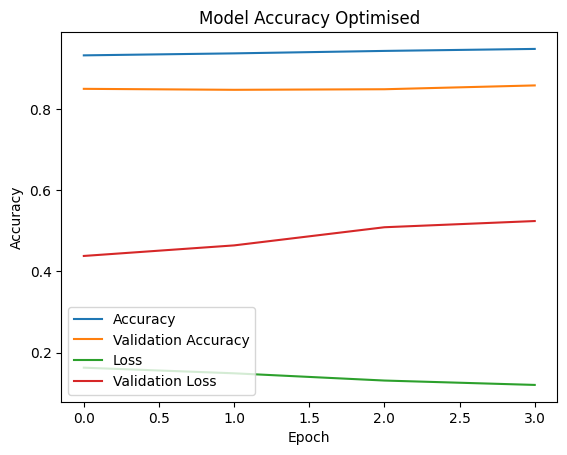

In [10]:
plt.plot(hist_top.history["accuracy"])
plt.plot(hist_top.history["val_accuracy"])
plt.plot(hist_top.history["loss"])
plt.plot(hist_top.history["val_loss"])

plt.title("Model Accuracy Optimised")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Accuracy", "Validation Accuracy", "Loss", "Validation Loss"])

plt.show()

## Guardado del modelo

In [11]:
model.save('image-classifier.keras')

## Comprobamos el funcionamento del modelo con unas imagenes externas

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


array([[0.25916824, 0.7408318 ]], dtype=float32)

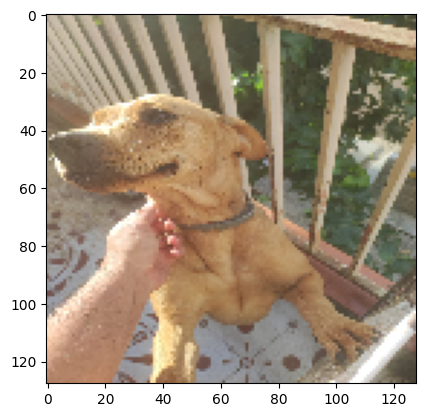

In [12]:
image = load_img('/content/drive/MyDrive/DataScience/dogs_vs_cats/out/new.jpg', target_size = (128, 128))
image = np.asarray(image)
image = image.astype('float32') / 255.0
plt.imshow(image)
image = np.expand_dims(image, axis=0)
image_classifier = load_model('image-classifier.keras')
pred = image_classifier.predict(image)
pred

>He probado el modelo con la perra de mis abuelos y ha decretado que es un perro con un 0.74 aproximadamente sobre un 0.26 de gato, ya que el modelo te da como primer valor la probabilidad de gato y como segundo la probabilidad de perro